# NB03 — Swarm Discovery and Endogenous Decentralized Architecture

## From Designed Coordination to Emergent Organization

### Introduction

Artificial-intelligence systems are usually introduced as if intelligence were located inside a model. A prompt enters, computation occurs, and an answer emerges. Multi-agent systems complicate this picture by distributing work across several specialized agents, but many of them preserve the same organizational intuition: somebody still designs the workflow. A coordinator decomposes the objective, assigns subtasks, gathers outputs, resolves conflicts, and decides what happens next. The individual agents may be sophisticated, yet the architecture that connects them remains largely exogenous.

This notebook explores a more radical possibility. What if the architecture required to solve a problem is not known beforehand? What if the system must discover not only the answer, but also the organization capable of finding that answer?

This question belongs to a broader sequence about **endogenous architectures**. In one approach, the system improves the improver: the mechanism responsible for producing better solutions itself becomes the object of recursive optimization. In another, an existing architecture becomes plastic: the system can modify roles, workflows, scaffolds, or configurations when the current structure proves inadequate. Both mechanisms relax the assumption that a human designer must permanently specify how the system operates. Yet they can still retain a recognizable locus of coordination.

A swarm pushes endogeneity further. We begin with heterogeneous agents rather than a finished organization. The agents possess different competencies, priors, search strategies, and cognitive lenses. They share an objective but are not told exactly how to divide the problem. They can search independently, encounter evidence, publish signals, request complementary expertise, respond to opportunities, form temporary contracts, build coalitions, abandon unproductive directions, and concentrate attention around increasingly promising hypotheses. The network of collaboration therefore changes through time.

The pedagogical metaphor is a treasure hunt inside an enormous, weakly structured library. Somewhere in that library lies the answer to an important question, but nobody knows which document contains the decisive clue or even which discipline supplies the correct language for interpreting it. A mathematician may notice a sequence that a historian would ignore. An engineer may recognize that an apparently ordinary patent solves a difficult physical constraint. A financial analyst may see that a technically excellent company is impossible to acquire because of leverage or ownership. No single agent has the complete lens.

The practical experiment translates this metaphor into investment banking. Our client is searching for an acquisition target with a very specific combination of characteristics: attractive financial performance, manageable leverage, relevant technology, defensible intellectual property, strategic access to Gulf markets, and evidence that the owners might realistically transact. We create a synthetic universe of companies and heterogeneous documentary clues. One company is deliberately constructed as the hidden treasure. Importantly, no single field or document announces that it is the answer. The swarm must assemble the case from distributed evidence.

The notebook therefore distinguishes **search** from **discovery**. Search is the act of examining information. Discovery is the process through which heterogeneous fragments become a sufficiently coherent hypothesis. A local clue can be valuable even when the agent finding it cannot interpret it completely. That creates a competence frontier: the point at which the expected return to continuing alone falls below the expected return to collaboration. At that frontier, an agent can emit what we call an **epistemic pheromone**—a structured signal containing evidence, confidence, location, novelty, and requested expertise. Other agents are free to ignore it. Coordination arises because another agent independently judges the signal worth pursuing.

This freedom is essential. A decentralized swarm is not merely a centralized workflow whose arrows have been hidden. Python will provide the environment: the simulation clock, document universe, message board, resource budgets, contracts, evidence ledger, bounty, and stopping rules. These are institutions, not a cognitive orchestrator. The agents themselves determine which evidence matters, which signals deserve attention, when collaboration is useful, and which relationships should form. In this sense the notebook is as much an experiment in institutional design as in artificial intelligence.

The network can be represented as a dynamic graph

$G_t=(V,E_t),$

where $V$ is the population of agents and $E_t$ contains the relationships that exist at time $t$. Initially, meaningful edges may be absent. As agents exchange information and collaborate, new edges appear. Coalitions can form around competing hypotheses. Some relationships disappear. Others become stronger. The topology is therefore an output of the search process rather than an input imposed by the designer.

This gives us a powerful definition of endogenous architecture: **the problem helps produce the organization that solves the problem**.

The notebook also introduces incentives. Successful discovery produces a bounty. Agents can therefore face a strategic choice between appropriation and collaboration. Keeping information private preserves the possibility of capturing more reward but may reduce the probability of success. Sharing information sacrifices some potential appropriation while making complementary expertise available. Contracts make that trade-off explicit. They need not be legally realistic contracts; pedagogically they are simple machine-readable agreements describing a proposed collaboration and a division of reward.

Claude serves as the reasoning engine for agent decisions, while deterministic Python handles the environment, accounting, reproducibility, and measurements. The notebook retrieves the API key from the Colab secret `ANTHROPIC_API_CORE_KEY`. The Claude model identifier is deliberately centralized in one configuration variable so it can be set to the exact Claude 5 Sonnet identifier available to the user without rewriting the notebook.

By the end, we will compare four organizational regimes: independent agents, a centrally coordinated architecture, a cooperative decentralized swarm, and a market-like swarm with endogenous contracting. We will evaluate not merely whether the hidden target is found, but how the organization behaves: search diversity, evidence coverage, signals, collaborations, concentration, false leads, cost, and time to discovery.

The deeper lesson is not that swarms are always superior. Central coordination can be efficient when the task structure is known. The question is when uncertainty about the structure of the problem becomes sufficiently important that decentralized exploration and endogenous organization create value.

We are therefore moving from designing solutions, to designing adaptive architectures, to designing **rules under which architectures can emerge**.

## Two Families of Endogeneity: Coordinated and Decentralized

Endogeneity does not imply the absence of structure. It means that some important component of the system's organization is determined during operation rather than completely fixed beforehand. The crucial distinction in this notebook is between **coordinated endogeneity** and **decentralized endogeneity**.

In a coordinated endogenous architecture, a recognizable coordinating mechanism remains responsible for observing performance and changing the system. The coordinator may reassign agents, modify prompts, select tools, create new roles, replace modules, or alter the workflow. The resulting architecture can be highly plastic because the system is not frozen. Nevertheless, adaptation has a locus. Information flows toward a mechanism capable of deciding that the current organization should change. The architecture is endogenous, but the process that produces architectural change remains comparatively centralized.

We can represent the idea schematically as

$\text{Coordinator} \rightarrow \text{Observe} \rightarrow \text{Evaluate} \rightarrow \text{Redesign} \rightarrow \text{Reassign}$

A decentralized endogenous architecture removes that privileged cognitive center. Individual agents observe only portions of the environment. They act using local information, different competencies, and potentially different incentives. Organization emerges through interaction. An agent may publish a signal because it has reached a competence frontier. Another may respond because the signal complements its expertise. A third may join because the coalition's hypothesis has become promising. No global planner needs to have anticipated the resulting team.

The corresponding process looks more like

$$
\text{Explore} \rightarrow \text{Signal} \rightarrow \text{Respond} \rightarrow \text{Contract} \rightarrow \text{Coalition} \rightarrow \text{Emergent }G_t.
$$

The distinction is not simply hierarchy versus chaos. A swarm still needs institutions. Communication must have a protocol. Resource budgets must exist. Evidence needs provenance. Contracts require a representation. Rewards require rules. The environment therefore establishes a constitutional layer while leaving the cognitive allocation of effort decentralized.

This distinction will be observable in the notebook. The centralized benchmark will explicitly allocate search according to a coordinating policy. The swarm regimes will instead allow agents to generate and follow signals. We can then ask an empirical question rather than assuming an ideological answer: under what conditions does each architecture discover the hidden target more efficiently, robustly, and economically?

The ultimate comparison is therefore between two forms of endogenous intelligence: **a system that can redesign itself through a coordinator and a population that can organize itself through interaction**.

## Cell 1 — Build the Hidden Acquisition Universe

The first requirement is an environment in which discovery is genuinely nontrivial. If the target can be identified by sorting a spreadsheet on EBITDA or searching for one keyword, a swarm adds little pedagogical value. We therefore create a synthetic investment-banking universe in which the correct acquisition target is defined by the **intersection** of several dimensions rather than by any single obvious feature.

Each company has structured financial information—revenue, EBITDA, leverage, geography, and ownership—as well as a collection of short unstructured documents representing annual-report language, patent notes, engineering commentary, market-access observations, and transaction-readiness signals. One company is deliberately planted as the hidden target. Its clues are distributed across different documents. Several decoys satisfy portions of the mandate so that superficial filtering produces false positives.

The environment knows the hidden answer because we need an objective benchmark. The agents do not receive that answer. This separation between environment truth and agent knowledge is fundamental. It allows us to measure whether the population discovers the target rather than accidentally being told it.

We also define the client's mandate in natural language. The mandate asks for a company with attractive EBITDA, manageable leverage, relevant desalination or water technology, defensible intellectual property, Gulf-market compatibility, and credible willingness to transact. These dimensions intentionally cross financial, technical, legal, strategic, and ownership expertise.

The output of this cell is therefore not simply a dataframe. It is the **search landscape** over which endogenous organization will later emerge. A good landscape contains both signal and ambiguity. Different specialists should notice different fragments, and no single specialist should be perfectly sufficient. This creates the complementarities required for collaboration to become economically and cognitively meaningful.


In [1]:
# CELL 1 — Build the Hidden Acquisition Universe
!pip -q install anthropic networkx

import os, json, random, math, textwrap, re
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Any, Optional
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

SEED = 766
random.seed(SEED)
np.random.seed(SEED)

CLIENT_MANDATE = """
Find an acquisition target with EBITDA of roughly USD 30–80m, manageable leverage,
defensible desalination/water technology, strong intellectual property, credible Gulf-market
compatibility, and evidence that the owners may realistically transact.
""".strip()

SPECIALTIES = [
    "finance", "engineering", "patents", "gulf_strategy", "ownership",
    "linguistic", "supply_chain", "valuation", "accounting", "synthesis"
]

def make_universe(n_companies=240):
    rows, docs = [], []
    regions = ["North America","Europe","Gulf","Asia","Latin America","Africa"]
    techs = ["industrial automation","water treatment","desalination membranes",
             "energy storage","industrial software","specialty chemicals"]
    ownerships = ["family-owned","private equity","founder-controlled","public","corporate carve-out"]

    for i in range(n_companies):
        cid = f"C{i:04d}"
        revenue = round(np.random.uniform(70, 900), 1)
        ebitda = round(np.random.uniform(8, 130), 1)
        leverage = round(np.random.uniform(0.2, 5.5), 2)
        region = random.choice(regions)
        tech = random.choice(techs)
        ownership = random.choice(ownerships)
        rows.append(dict(company_id=cid, name=f"Company {i:04d}", revenue_m=revenue,
                         ebitda_m=ebitda, leverage=leverage, region=region,
                         technology=tech, ownership=ownership))

        snippets = [
            ("annual_report", f"{cid} reports EBITDA near {ebitda}m and leverage of {leverage}x; management emphasizes disciplined capital allocation."),
            ("engineering", f"Engineering note for {cid}: platform focus is {tech}; field performance varies by salinity and operating environment."),
            ("patent", f"Patent review for {cid}: portfolio contains incremental process claims and selected proprietary designs."),
            ("market", f"Commercial note for {cid}: international expansion remains selective; regional partnerships are under review."),
            ("ownership", f"Ownership note for {cid}: structure is {ownership}; no explicit sale process has been announced.")
        ]
        for j,(dtype,txt) in enumerate(snippets):
            docs.append(dict(doc_id=f"{cid}_D{j}", company_id=cid, doc_type=dtype, text=txt))

    # Plant target in a non-obvious company and distribute clues across documents.
    target_idx = 173
    target_id = f"C{target_idx:04d}"
    for r in rows:
        if r["company_id"] == target_id:
            r.update(ebitda_m=58.0, leverage=1.65, region="Europe",
                     technology="desalination membranes", ownership="family-owned")

    planted = [
        ("annual_report", "EBITDA is approximately USD 58m with net leverage around 1.65x; recurring service revenue has improved cash conversion."),
        ("engineering", "Pilot systems maintain unusually strong efficiency under high-salinity and high-temperature operating conditions relevant to large coastal desalination plants."),
        ("patent", "The company controls a concentrated family of membrane-coating claims with long remaining life and difficult-to-replicate manufacturing know-how."),
        ("market", "A recently certified Gulf distributor and two engineering partnerships provide a credible route into Saudi and UAE water infrastructure programs."),
        ("ownership", "Second-generation family shareholders have begun succession planning and retained advisers to evaluate strategic partnerships, minority investment, or a possible full exit.")
    ]
    docs = [d for d in docs if d["company_id"] != target_id]
    for j,(dtype,txt) in enumerate(planted):
        docs.append(dict(doc_id=f"{target_id}_D{j}", company_id=target_id, doc_type=dtype, text=txt))

    # Create strong decoys that satisfy only subsets.
    decoys = {
        "C0042": [
            ("engineering","Advanced desalination membrane platform demonstrates strong technical performance in brackish water."),
            ("patent","Broad patent portfolio protects several membrane configurations and process improvements.")
        ],
        "C0091": [
            ("annual_report","EBITDA is approximately USD 63m, but net leverage has risen to 4.9x after an acquisition program."),
            ("market","Longstanding Gulf commercial relationships include Saudi and UAE distributors.")
        ],
        "C0211": [
            ("ownership","Private-equity sponsor is actively evaluating exit alternatives and has appointed financial advisers."),
            ("annual_report","EBITDA is approximately USD 55m with moderate leverage."),
            ("engineering","Core technology is industrial automation rather than water treatment.")
        ]
    }
    for cid, additions in decoys.items():
        docs = [d for d in docs if not (d["company_id"]==cid and d["doc_type"] in [x[0] for x in additions])]
        base = len([d for d in docs if d["company_id"]==cid])
        for j,(dtype,txt) in enumerate(additions):
            docs.append(dict(doc_id=f"{cid}_X{base+j}", company_id=cid, doc_type=dtype, text=txt))

    return pd.DataFrame(rows), pd.DataFrame(docs), target_id

companies, documents, HIDDEN_TARGET = make_universe()
print("Companies:", len(companies), "| Documents:", len(documents))
print("Client mandate:", CLIENT_MANDATE)
print("Hidden target is retained by the environment for evaluation only.")
display(companies.head())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 15.5 MB/s eta 0:00:00
Companies: 240 | Documents: 1200
Client mandate: Find an acquisition target with EBITDA of roughly USD 30–80m, manageable leverage,
defensible desalination/water technology, strong intellectual property, credible Gulf-market
compatibility, and evidence that the owners may realistically transact.
Hidden target is retained by the environment for evaluation only.


,company_id,name,revenue_m,ebitda_m,leverage,region,technology,ownership
0,C0000,Company 0000,558.9,67.1,3.14,Gulf,water treatment,founder-controlled
1,C0001,Company 0001,80.8,19.8,4.79,Gulf,desalination membranes,private equity
2,C0002,Company 0002,496.3,129.9,3.35,Gulf,industrial software,corporate carve-out
3,C0003,Company 0003,106.3,17.4,3.61,North America,desalination membranes,corporate carve-out
4,C0004,Company 0004,772.3,119.5,0.80,Asia,industrial software,founder-controlled


## Cell 2 — Release the Heterogeneous Swarm

A swarm becomes interesting only when its members are meaningfully heterogeneous. Creating twenty identical prompts and calling them twenty agents produces parallel sampling, not an artificial society. In this cell we define agents with different specializations, vocabularies, priors, and search heuristics. Their diversity is intentional because the hidden target has been constructed to require multiple lenses.

We create specialists in financial analysis, engineering, patents and intellectual property, Gulf-market strategy, ownership and transaction readiness, linguistic anomaly detection, supply chains, valuation, accounting, and general investigative synthesis. Each agent receives a small resource budget and a compact role description. Importantly, no agent receives a preassigned company. The population knows the common objective, but each member decides which evidence is salient through its own expertise.

Claude is introduced here as the reasoning engine. The notebook retrieves the API key from the Colab secret named `ANTHROPIC_API_CORE_KEY`. The model identifier is held in one variable, `CLAUDE_MODEL`. This makes the notebook robust to changes in Anthropic's exact production model naming: the user only needs to update one line with the Claude 5 Sonnet identifier available in the account.

We also provide a deterministic fallback mode. This is pedagogically useful and cost-conscious: the full simulation can be executed without API calls, while selected agent decisions can be delegated to Claude when desired. The fallback is not meant to imitate frontier reasoning perfectly. It ensures that students can study the architecture, graph dynamics, incentives, and metrics even if an API is temporarily unavailable.

The essential object produced by this cell is the population \(V\) in our dynamic graph \(G_t=(V,E_t)\). At this moment, agents exist, but meaningful collaborative edges do not. Organization has not yet emerged.


In [4]:
# CELL 2 — Release the Heterogeneous Swarm

from google.colab import userdata
try:
    from anthropic import Anthropic
except Exception:
    Anthropic = None

# Exact secret name requested for Colab:
ANTHROPIC_API_KEY = userdata.get("ANTHROPIC_API_KEY")

# Set this to the exact Claude 5 Sonnet model ID enabled in your Anthropic account.
CLAUDE_MODEL = "claude-sonnet-5"

# Keep False for the inexpensive deterministic demonstration.
# Turn True after setting CLAUDE_MODEL to use Claude for selected reasoning decisions.
USE_CLAUDE = False
MAX_API_CALLS = 30
api_calls = 0

client = Anthropic(api_key=ANTHROPIC_API_KEY) if (Anthropic and ANTHROPIC_API_KEY) else None

@dataclass
class Agent:
    agent_id: str
    specialty: str
    budget: int = 18
    evidence: List[Dict[str,Any]] = field(default_factory=list)
    signals_seen: set = field(default_factory=set)
    contracts: List[str] = field(default_factory=list)

specialty_cycle = SPECIALTIES * 3
agents = [Agent(f"A{i:02d}", specialty_cycle[i]) for i in range(30)]

ROLE_HINTS = {
    "finance":"EBITDA leverage cash conversion financial quality",
    "engineering":"desalination membrane salinity temperature engineering efficiency",
    "patents":"patent claims intellectual property proprietary defensible know-how",
    "gulf_strategy":"Gulf Saudi UAE distributor certification partnership market",
    "ownership":"family succession exit adviser sale ownership transact",
    "linguistic":"strategic alternatives evaluate partnership unusual language signal",
    "supply_chain":"supplier manufacturing distribution capacity route",
    "valuation":"EBITDA leverage valuation recurring revenue cash",
    "accounting":"EBITDA leverage revenue cash accounting",
    "synthesis":"EBITDA leverage desalination patent Gulf exit family"
}

def claude_text(system, prompt, max_tokens=500):
    global api_calls
    if not USE_CLAUDE:
        return None
    if client is None:
        raise RuntimeError("Anthropic client unavailable. Check the Colab secret.")
    if CLAUDE_MODEL.startswith("YOUR_"):
        raise RuntimeError("Set CLAUDE_MODEL to the exact Claude 5 Sonnet model ID available in your account.")
    if api_calls >= MAX_API_CALLS:
        raise RuntimeError("MAX_API_CALLS reached.")
    api_calls += 1
    msg = client.messages.create(
        model=CLAUDE_MODEL,
        max_tokens=max_tokens,
        system=system,
        messages=[{"role":"user","content":prompt}]
    )
    return "".join(getattr(x, "text", "") for x in msg.content)

print(f"Released {len(agents)} heterogeneous agents.")
display(pd.DataFrame([asdict(a) | {"evidence":0, "signals_seen":0, "contracts":0} for a in agents]).head(12))


Released 30 heterogeneous agents.


,agent_id,specialty,budget,evidence,signals_seen,contracts
0,A00,finance,18,0,0,0
1,A01,engineering,18,0,0,0
2,A02,patents,18,0,0,0
3,A03,gulf_strategy,18,0,0,0
4,A04,ownership,18,0,0,0
5,A05,linguistic,18,0,0,0
6,A06,supply_chain,18,0,0,0
7,A07,valuation,18,0,0,0
8,A08,accounting,18,0,0,0
9,A09,synthesis,18,0,0,0


## Cell 3 — Independent Exploration

We begin with a deliberately decentralized initial condition. Agents search independently, using their specializations to score which documents appear most relevant. This stage establishes exploratory diversity before social information begins to influence behavior. It also gives us a baseline for understanding why communication later matters.

Each agent inspects a limited number of documents. Scarcity is important. If every agent can instantly read the entire corpus, there is little reason to specialize, signal, or collaborate. Search budgets create an allocation problem: attention is costly, and agents must decide where to spend it. The notebook therefore models a simple form of bounded rationality. Agents have powerful reasoning but incomplete information and finite search capacity.

The deterministic search function uses specialization-sensitive keyword mappings to approximate different cognitive lenses. A patent specialist responds strongly to terms such as claims, membrane, patent, and intellectual property. A finance specialist notices EBITDA and leverage. A Gulf-market specialist recognizes regional certification, Arabic-market distribution, and local partnerships. When Claude mode is enabled, the LLM can instead rank a candidate subset and explain why particular documents deserve inspection.

At this stage agents do not yet share what they find. Their evidence ledgers are private. This lets us visualize the initial dispersion of attention and calculate search diversity. Some agents will inspect the hidden target's documents, but they may not appreciate the full significance because the clue lies outside their specialization.

This is exactly the condition we want. Local intelligence exists, but collective intelligence has not yet formed. The swarm begins as a population of competent but epistemically isolated searchers. The next stages will ask whether weak local discoveries can become social signals capable of reorganizing the population.


In [5]:
# CELL 3 — Independent Exploration

def keyword_score(text, specialty):
    words = ROLE_HINTS[specialty].lower().split()
    t = text.lower()
    return sum(t.count(w) for w in words)

def independent_explore(agent, docs, k=6):
    sample = docs.sample(min(90, len(docs)), random_state=SEED + int(agent.agent_id[1:]))
    sample = sample.copy()
    sample["score"] = sample["text"].map(lambda x: keyword_score(x, agent.specialty))
    # Mix exploitation with exploration.
    top = sample.sort_values(["score","doc_id"], ascending=[False,True]).head(max(1,k-2))
    random_part = sample.drop(top.index).sample(min(2, len(sample)-len(top)),
                                                random_state=SEED*2 + int(agent.agent_id[1:]))
    chosen = pd.concat([top, random_part]).drop_duplicates("doc_id").head(k)
    agent.budget -= len(chosen)
    return chosen

search_log = []
for a in agents:
    chosen = independent_explore(a, documents, k=6)
    for _, d in chosen.iterrows():
        search_log.append({"agent_id":a.agent_id, "specialty":a.specialty,
                           "doc_id":d.doc_id, "company_id":d.company_id,
                           "doc_type":d.doc_type, "text":d.text})

search_df = pd.DataFrame(search_log)
print("Independent inspections:", len(search_df))
print("Distinct companies inspected:", search_df.company_id.nunique())
display(search_df.head(10))


Independent inspections: 180
Distinct companies inspected: 114


,agent_id,specialty,doc_id,company_id,doc_type,text
0,A00,finance,C0015_D0,C0015,annual_report,C0015 reports EBITDA near 40.4m and leverage o...
1,A00,finance,C0019_D0,C0019,annual_report,C0019 reports EBITDA near 79.2m and leverage o...
2,A00,finance,C0037_D0,C0037,annual_report,C0037 reports EBITDA near 10.0m and leverage o...
3,A00,finance,C0042_D0,C0042,annual_report,C0042 reports EBITDA near 86.2m and leverage o...
4,A00,finance,C0001_D1,C0001,engineering,Engineering note for C0001: platform focus is ...
5,A00,finance,C0084_D2,C0084,patent,Patent review for C0084: portfolio contains in...
6,A01,engineering,C0009_D1,C0009,engineering,Engineering note for C0009: platform focus is ...
7,A01,engineering,C0027_D1,C0027,engineering,Engineering note for C0027: platform focus is ...
8,A01,engineering,C0076_D1,C0076,engineering,Engineering note for C0076: platform focus is ...
9,A01,engineering,C0025_D1,C0025,engineering,Engineering note for C0025: platform focus is ...


## Cell 4 — Convert Search into Local Discoveries

Reading a document is not the same as producing useful knowledge. In this cell, observations become structured discoveries. Each inspected document is converted into an evidence object containing the company, document type, observed clue, relevance score, agent identity, confidence, and a short hypothesis. This creates a provenance-preserving ledger of what each agent actually knows.

The distinction between evidence and hypothesis matters. An engineering note might say that a membrane system operates efficiently under high-salinity conditions. That is evidence. The hypothesis might be that the company possesses technology particularly suitable for Gulf desalination markets. A patent specialist might separately find strong claims around the same membrane architecture. Neither observation alone proves that the company is the acquisition target. Together, however, they can become substantially more informative.

Confidence is intentionally local. Agents should not pretend to know the global probability that a company is the answer. Instead, they estimate how strongly a piece of evidence supports the mandate from their own cognitive perspective. This preserves heterogeneity and prevents premature consensus.

The notebook aggregates discoveries only for visualization and evaluation; the agents' operational knowledge remains represented through their own ledgers and the signals they later choose to publish. This separation helps us avoid accidentally recreating a hidden orchestrator. A central dataframe may record events for the experimenter without becoming a decision-making brain for the swarm.

We will see many mediocre discoveries, several attractive false leads, and a few highly valuable fragments. That distribution is desirable. Swarm intelligence does not require every local judgment to be correct. It requires mechanisms through which useful information can propagate, complementary expertise can be recruited, and weak evidence can be combined into stronger collective hypotheses.


In [11]:
# CELL 4 — Convert Search into Local Discoveries

MANDATE_TERMS = {
    "finance":["ebitda","leverage","cash conversion","recurring"],
    "engineering":["desalination","membrane","salinity","temperature","efficiency"],
    "patents":["patent","claims","proprietary","know-how","intellectual"],
    "gulf_strategy":["gulf","saudi","uae","certified","distributor","partnership"],
    "ownership":["family","succession","exit","adviser","sale","strategic"],
    "linguistic":["evaluate","strategic","alternatives","possible","retained"],
    "supply_chain":["manufacturing","supplier","distribution","capacity"],
    "valuation":["ebitda","leverage","cash","revenue"],
    "accounting":["ebitda","leverage","cash","revenue"],
    "synthesis":["ebitda","leverage","desalination","membrane","patent","gulf","exit","family"]
}

def make_discovery(row):
    terms = MANDATE_TERMS[row.specialty]
    hits = [w for w in terms if w in row.text.lower()]
    confidence = min(0.95, 0.12 + 0.12*len(hits))
    novelty = min(1.0, 0.20 + 0.10*len(set(hits)))
    return {
        "agent_id":row.agent_id, "specialty":row.specialty,
        "company_id":row.company_id, "doc_id":row.doc_id,
        "doc_type":row.doc_type, "evidence":row.text,
        "hits":hits, "confidence":round(confidence,3),
        "novelty":round(novelty,3),
        "hypothesis":f"{row.company_id} may satisfy part of the mandate from a {row.specialty} perspective."
    }

discoveries = [make_discovery(r) for r in search_df.itertuples()]
discovery_df = pd.DataFrame(discoveries)

agent_map = {a.agent_id:a for a in agents}
for d in discoveries:
    agent_map[d["agent_id"]].evidence.append(d)

print("Local discoveries:", len(discovery_df))
display(discovery_df.sort_values("confidence", ascending=False).head(12))


Local discoveries: 180


,agent_id,specialty,company_id,doc_id,doc_type,evidence,hits,confidence,novelty,hypothesis
102,A17,valuation,C0173,C0173_D0,annual_report,EBITDA is approximately USD 58m with net lever...,"[ebitda, leverage, cash, revenue]",0.60,0.6,C0173 may satisfy part of the mandate from a v...
17,A02,patents,C0185,C0185_D2,patent,Patent review for C0185: portfolio contains in...,"[patent, claims, proprietary]",0.48,0.5,C0185 may satisfy part of the mandate from a p...
6,A01,engineering,C0009,C0009_D1,engineering,Engineering note for C0009: platform focus is ...,"[desalination, membrane, salinity]",0.48,0.5,C0009 may satisfy part of the mandate from a e...
8,A01,engineering,C0076,C0076_D1,engineering,Engineering note for C0076: platform focus is ...,"[desalination, membrane, salinity]",0.48,0.5,C0076 may satisfy part of the mandate from a e...
15,A02,patents,C0057,C0057_D2,patent,Patent review for C0057: portfolio contains in...,"[patent, claims, proprietary]",0.48,0.5,C0057 may satisfy part of the mandate from a p...
14,A02,patents,C0040,C0040_D2,patent,Patent review for C0040: portfolio contains in...,"[patent, claims, proprietary]",0.48,0.5,C0040 may satisfy part of the mandate from a p...
13,A02,patents,C0038,C0038_D2,patent,Patent review for C0038: portfolio contains in...,"[patent, claims, proprietary]",0.48,0.5,C0038 may satisfy part of the mandate from a p...
12,A02,patents,C0028,C0028_D2,patent,Patent review for C0028: portfolio contains in...,"[patent, claims, proprietary]",0.48,0.5,C0028 may satisfy part of the mandate from a p...
135,A22,patents,C0072,C0072_D2,patent,Patent review for C0072: portfolio contains in...,"[patent, claims, proprietary]",0.48,0.5,C0072 may satisfy part of the mandate from a p...
134,A22,patents,C0043,C0043_D2,patent,Patent review for C0043: portfolio contains in...,"[patent, claims, proprietary]",0.48,0.5,C0043 may satisfy part of the mandate from a p...


## Cell 5 — Epistemic Pheromones: Signaling Without Command

This cell introduces the central communication mechanism: the epistemic pheromone. When an agent encounters evidence that is interesting but incomplete, it may publish a structured signal to the shared message board. The signal identifies the company, evidence, confidence, novelty, the sender's specialization, and—crucially—the type of expertise that could increase the value of the lead.

A signal is not an instruction. No receiving agent is required to respond. This is the difference between communication and orchestration. The sender says, in effect, “I have encountered something unusual; here is why I think it matters; here is the capability I lack.” Other agents independently evaluate whether following the lead has positive expected value.

Signals are emitted only above a threshold. This prevents the message board from becoming an indiscriminate dump of every observation. In a richer implementation, agents could learn optimal signaling thresholds, reputation could affect signal credibility, and bandwidth could itself be scarce. Here we use a transparent rule so students can see the mechanism clearly.

The message board becomes a form of shared external memory. It resembles pheromone trails in biological swarms because individual local actions modify the informational environment encountered by others. Yet these artificial pheromones are semantic: they carry hypotheses, confidence, provenance, and requests for expertise.

Once signals exist, the population's search distribution can begin to change. A patent agent that would never independently inspect a particular company may redirect attention because an engineering specialist found an unusual technology clue there. Coordination has emerged without a task assignment.

This is the first point at which the graph \(G_t\) begins acquiring informational edges. Those edges do not yet imply formal collaboration. They record influence: one agent's discovery has altered another agent's opportunity set.


In [12]:
# CELL 5 — Epistemic Pheromones: Signaling Without Command

COMPLEMENT = {
    "finance":"engineering", "engineering":"patents", "patents":"gulf_strategy",
    "gulf_strategy":"ownership", "ownership":"finance", "linguistic":"ownership",
    "supply_chain":"engineering", "valuation":"ownership", "accounting":"finance",
    "synthesis":"patents"
}

signals = []
signal_id = 0

for d in discoveries:
    # Threshold allows strong local clues to enter shared memory.
    if d["confidence"] >= 0.36 and d["novelty"] >= 0.40:
        signals.append({
            "signal_id":f"S{signal_id:03d}",
            "sender":d["agent_id"],
            "sender_specialty":d["specialty"],
            "company_id":d["company_id"],
            "confidence":d["confidence"],
            "novelty":d["novelty"],
            "requested_expertise":COMPLEMENT[d["specialty"]],
            "evidence":d["evidence"],
            "hypothesis":d["hypothesis"]
        })
        signal_id += 1

signal_df = pd.DataFrame(signals)
print("Signals emitted:", len(signal_df))
if len(signal_df):
    display(signal_df.sort_values(["confidence","novelty"], ascending=False).head(15))
else:
    print("No signals crossed the threshold; lower thresholds for experimentation.")


Signals emitted: 81


,signal_id,sender,sender_specialty,company_id,confidence,novelty,requested_expertise,evidence,hypothesis
42,S042,A17,valuation,C0173,0.60,0.6,ownership,EBITDA is approximately USD 58m with net lever...,C0173 may satisfy part of the mandate from a v...
4,S004,A01,engineering,C0009,0.48,0.5,patents,Engineering note for C0009: platform focus is ...,C0009 may satisfy part of the mandate from a e...
5,S005,A01,engineering,C0027,0.48,0.5,patents,Engineering note for C0027: platform focus is ...,C0027 may satisfy part of the mandate from a e...
6,S006,A01,engineering,C0076,0.48,0.5,patents,Engineering note for C0076: platform focus is ...,C0076 may satisfy part of the mandate from a e...
7,S007,A02,patents,C0028,0.48,0.5,gulf_strategy,Patent review for C0028: portfolio contains in...,C0028 may satisfy part of the mandate from a p...
8,S008,A02,patents,C0038,0.48,0.5,gulf_strategy,Patent review for C0038: portfolio contains in...,C0038 may satisfy part of the mandate from a p...
9,S009,A02,patents,C0040,0.48,0.5,gulf_strategy,Patent review for C0040: portfolio contains in...,C0040 may satisfy part of the mandate from a p...
10,S010,A02,patents,C0057,0.48,0.5,gulf_strategy,Patent review for C0057: portfolio contains in...,C0057 may satisfy part of the mandate from a p...
11,S011,A02,patents,C0185,0.48,0.5,gulf_strategy,Patent review for C0185: portfolio contains in...,C0185 may satisfy part of the mandate from a p...
31,S031,A11,engineering,C0008,0.48,0.5,patents,Engineering note for C0008: platform focus is ...,C0008 may satisfy part of the mandate from a e...


## Cell 6 — Competence Frontiers and Voluntary Response

A central proposition of this notebook is that collaboration should arise because agents encounter the limits of their own competence. We call this boundary a **competence frontier**. An agent may recognize that a lead is valuable while simultaneously recognizing that additional work using the same expertise has declining marginal value.

Suppose an engineering specialist finds evidence of an unusual membrane technology. Continuing to read engineering documents may add little. A patent specialist could determine whether the technology is defensible. A Gulf-market specialist could evaluate regional applicability. A financial analyst could test whether the economics satisfy the mandate. The rational next action is therefore not necessarily “search harder.” It may be “recruit a complementary mind.”

In this cell, agents inspect the message board and calculate a simple expected-value score for responding to signals. Compatibility between requested expertise and the receiving agent's specialization increases expected value. Signal confidence and novelty increase it further, while search cost reduces it. Agents respond only when the resulting value crosses a threshold.

This mechanism is intentionally local. There is no central function selecting the globally optimal responder. Several agents may respond to the same signal; none may respond to a weak signal. This permits redundancy, competition, and occasional inefficiency—the characteristics that make decentralized systems genuinely different from centrally optimized workflows.

When an agent responds, it examines additional evidence concerning the signaled company through its own specialization. The original clue is therefore transformed by another cognitive lens. If the new evidence is useful, confidence around the hypothesis may increase. If it is contradictory, the lead may weaken.

The result is a crucial transition: the swarm begins to allocate resources according to **socially generated information** rather than purely independent priors. Search behavior becomes endogenous to the discoveries of the population.


In [13]:
# CELL 6 — Competence Frontiers and Voluntary Response

responses = []
response_evidence = []

def response_value(agent, signal):
    compatibility = 1.0 if agent.specialty == signal["requested_expertise"] else 0.25
    same_sender_penalty = -1.0 if agent.agent_id == signal["sender"] else 0.0
    return (1.8*signal["confidence"] + 1.2*signal["novelty"] +
            1.1*compatibility + same_sender_penalty - 0.55)

for s in signals:
    candidates = []
    for a in agents:
        ev = response_value(a, s)
        if ev > 1.25 and a.budget > 0:
            candidates.append((ev,a))
    # No central optimal assignment: every eligible agent could respond.
    # We cap to two responses per signal only as an environmental resource constraint.
    for ev,a in sorted(candidates, key=lambda x:x[0], reverse=True)[:2]:
        company_docs = documents[documents.company_id == s["company_id"]].copy()
        company_docs["local_score"] = company_docs.text.map(lambda x: keyword_score(x, a.specialty))
        d = company_docs.sort_values("local_score", ascending=False).iloc[0]
        a.budget -= 1
        a.signals_seen.add(s["signal_id"])
        responses.append({
            "signal_id":s["signal_id"], "sender":s["sender"],
            "responder":a.agent_id, "responder_specialty":a.specialty,
            "company_id":s["company_id"], "expected_value":round(ev,3)
        })
        rr = make_discovery(type("R", (), dict(
            agent_id=a.agent_id, specialty=a.specialty, company_id=d.company_id,
            doc_id=d.doc_id, doc_type=d.doc_type, text=d.text
        ))())
        a.evidence.append(rr)
        response_evidence.append(rr)

response_df = pd.DataFrame(responses)
response_evidence_df = pd.DataFrame(response_evidence)
print("Voluntary responses:", len(response_df))
display(response_df.head(15))


Voluntary responses: 141


,signal_id,sender,responder,responder_specialty,company_id,expected_value
0,S000,A00,A01,engineering,C0015,1.678
1,S000,A00,A11,engineering,C0015,1.678
2,S001,A00,A01,engineering,C0019,1.678
3,S001,A00,A11,engineering,C0019,1.678
4,S002,A00,A01,engineering,C0037,1.678
5,S002,A00,A11,engineering,C0037,1.678
6,S003,A00,A01,engineering,C0042,1.678
7,S003,A00,A11,engineering,C0042,1.678
8,S004,A01,A02,patents,C0009,2.014
9,S004,A01,A12,patents,C0009,2.014


### How Signals and Responses Work

1.  **Signals are Broadcast:** Agents (senders) broadcast signals, effectively posting them to a shared 'message board' that all other agents can access. This is implied by the `for s in signals:` loop, where each signal `s` is iterated over by every agent `a` (`for a in agents:`).

2.  **Voluntary Response:** Instead of a bidding process, other agents `a` *voluntarily evaluate* each signal `s` to determine if they should respond. They do this by calculating a `response_value` which considers:
    *   `signal["confidence"]` and `signal["novelty"]` (strength of the signal).
    *   `compatibility`: If the `agent.specialty` matches the `signal["requested_expertise"]`, the value increases significantly. This encourages specialists to respond to relevant signals.
    *   `same_sender_penalty`: To prevent an agent from repeatedly responding to their own signals.
    *   `agent.budget`: Agents only respond if they have enough budget.

3.  **No Central Assignment or Bidding:** The notebook explicitly states: "No central optimal assignment: every eligible agent could respond." This means there isn't a 'sender' agent evaluating bids. Instead, agents decide *independently* whether to respond. To manage resources, the simulation caps responses to the top two candidates per signal based on their calculated `response_value`.



### What Happens if Multiple Agents Respond to a Signal?

1.  **Signal Evaluation:** Every agent `a` evaluates every signal `s` by calculating a `response_value`. This value considers factors like the signal's confidence and novelty, the agent's specialty compatibility, and the agent's budget.

2.  **Candidate Responders:** Any agent with a `response_value` above a certain threshold (in the code, `ev > 1.25`) and sufficient budget (`a.budget > 0`) becomes a potential candidate to respond to that signal.

3.  **Capping Responses:** The system does *not* allow all eligible candidates to respond. Instead, it caps the number of actual responses to **the top two candidates** for each signal. This is explicitly stated and implemented with `sorted(candidates, key=lambda x:x[0], reverse=True)[:2]`.

    *   `sorted(candidates, key=lambda x:x[0], reverse=True)`: This sorts all eligible candidate agents for a given signal in descending order based on their calculated `response_value`.
    *   `[:2]`: This slices the sorted list, taking only the first two agents (those with the highest `response_value`).

**In summary:** If multiple agents are *eligible* and *want* to respond to a single signal, only the two agents with the highest calculated `response_value` will actually generate a response and form a contract with the signal's sender. This introduces a form of competition among potential responders for the opportunity to collaborate on a given signal.

## Cell 7 — Endogenous Contracting and the Bounty

Communication alone creates cooperation, but incentives make the architecture strategically interesting. This cell introduces a simple bounty for successful identification of the hidden acquisition target. Agents can propose collaboration contracts that specify a company hypothesis, participating agents, and a proposed division of the reward.

The contract is deliberately minimal. Its purpose is not to reproduce legal contracting. It represents an economic commitment: “I will reveal and combine my information with yours if we agree how the potential value of discovery will be shared.” This creates a tension between appropriation and collaboration.

An agent with a moderately promising private lead can continue alone and preserve the possibility of capturing the full bounty. Yet doing so may leave important competence gaps unresolved. Alternatively, it can share information, recruit complementary expertise, and accept a smaller percentage of a discovery that becomes much more likely. The swarm therefore contains a primitive market for intelligence.

Contracts are generated from actual signals and responses rather than from a predefined team structure. This is essential. We do not tell the engineering, patent, finance, and Gulf specialists that they form Team A. Instead, a particular company's evidence creates a reason for those agents to associate. Another company may produce a completely different coalition.

The notebook records contracts as edges in the dynamic network. Edge weights can reflect the strength of collaboration or the amount of evidence exchanged. We can therefore watch the graph become denser around hypotheses that attract complementary expertise.

This cell moves the experiment from collective search toward endogenous organization. The architecture is no longer simply “agents connected to a message board.” Problem-specific suborganizations are appearing. Their membership, purpose, and duration are consequences of discoveries made during the search.


### How Contracts Form

1.  **Bilateral Contracts:** Once an agent responds to a signal, a simple *bilateral contract* is immediately formed between the original `sender` of the signal and the `responder` agent. This isn't negotiated or bid upon.

2.  **Predetermined Share Division:** The `shares` of the potential `BOUNTY` (which is set at `100.0`) are determined algorithmically based on the original signal's confidence:
    *   `sender_share` is calculated as `0.50 + 0.10 * (next(s for s in signals if s["signal_id"]==r["signal_id"])["confidence"] - 0.5)`, with caps between 0.45 and 0.65.
    *   `responder_share` is simply `1.0 - sender_share`.

So, while the goal of the contracts is to share a potential bounty, the decision to form a contract and the share division are pre-programmed based on the signal and response, not through a dynamic bidding or acceptance process by the sending agent.

In [15]:
# CELL 7 — Endogenous Contracting and the Bounty

BOUNTY = 100.0
contracts = []

for i, r in enumerate(responses):
    # A simple bilateral contract generated by a signal-response pair.
    sender_share = round(0.50 + 0.10*(next(s for s in signals if s["signal_id"]==r["signal_id"])["confidence"]-0.5), 2)
    sender_share = min(0.65, max(0.45, sender_share))
    responder_share = round(1.0 - sender_share, 2)
    cid = f"K{i:03d}"
    contract = {
        "contract_id":cid,
        "company_id":r["company_id"],
        "members":[r["sender"], r["responder"]],
        "shares":{r["sender"]:sender_share, r["responder"]:responder_share},
        "status":"accepted",
        "origin_signal":r["signal_id"]
    }
    contracts.append(contract)
    agent_map[r["sender"]].contracts.append(cid)
    agent_map[r["responder"]].contracts.append(cid)

contract_df = pd.DataFrame([{
    "contract_id":c["contract_id"], "company_id":c["company_id"],
    "members":" + ".join(c["members"]),
    "shares":json.dumps(c["shares"]), "status":c["status"],
    "origin_signal":c["origin_signal"]
} for c in contracts])

print("Accepted endogenous contracts:", len(contract_df))
display(contract_df.head(15))


Accepted endogenous contracts: 141


,contract_id,company_id,members,shares,status,origin_signal
0,K000,C0015,A00 + A01,"{""A00"": 0.49, ""A01"": 0.51}",accepted,S000
1,K001,C0015,A00 + A11,"{""A00"": 0.49, ""A11"": 0.51}",accepted,S000
2,K002,C0019,A00 + A01,"{""A00"": 0.49, ""A01"": 0.51}",accepted,S001
3,K003,C0019,A00 + A11,"{""A00"": 0.49, ""A11"": 0.51}",accepted,S001
4,K004,C0037,A00 + A01,"{""A00"": 0.49, ""A01"": 0.51}",accepted,S002
5,K005,C0037,A00 + A11,"{""A00"": 0.49, ""A11"": 0.51}",accepted,S002
6,K006,C0042,A00 + A01,"{""A00"": 0.49, ""A01"": 0.51}",accepted,S003
7,K007,C0042,A00 + A11,"{""A00"": 0.49, ""A11"": 0.51}",accepted,S003
8,K008,C0009,A01 + A02,"{""A01"": 0.5, ""A02"": 0.5}",accepted,S004
9,K009,C0009,A01 + A12,"{""A01"": 0.5, ""A12"": 0.5}",accepted,S004


### Endogenous Contracting and the Bounty

Cell 7 introduces the concept of **endogenous contracting** within the agent swarm. This is where the initial cooperation (signal-response) transitions into a more structured economic commitment, driven by the potential for a `BOUNTY`.

Here's a breakdown of what happens:

1.  **Purpose of Contracts:** The contracts are not literal legal documents but represent an *economic commitment*. They allow agents to combine information and expertise by agreeing on how the potential value of a discovery (the `BOUNTY`) will be shared. This creates a tension: an agent can pursue a lead alone for a larger share, or collaborate to increase the likelihood of success, accepting a smaller percentage.

2.  **Contract Generation:** Contracts are generated directly from the responses recorded in Cell 6. For each `response` (`r`) identified in the previous step, a bilateral contract is formed.

3.  **Members and Shares:**
    *   Each contract involves two `members`: the `sender` of the original signal and the `responder` agent.
    *   The `BOUNTY` is a fixed amount (e.g., `100.0`).
    *   `sender_share` and `responder_share` are calculated based on the `confidence` of the original signal. Higher signal confidence means the sender retains a slightly larger share. The shares are capped between 45% and 65% for the sender, with the responder receiving the remainder.
    *   The status is immediately set to "accepted," meaning there's no negotiation phase in this model.

4.  **Contract Recording:**
    *   Each contract is assigned a unique `contract_id`.
    *   It links to the `company_id` and `origin_signal` that initiated it.
    *   The generated contract details are appended to the `contracts` list.
    *   Each agent involved (sender and responder) has the `contract_id` added to its `agent.contracts` list.

5.  **Output:** The cell then displays a DataFrame (`contract_df`) summarizing the `Accepted endogenous contracts`, showing the contract ID, company, members, their shares, status, and the originating signal.

This mechanism demonstrates how problem-specific sub-organizations (coalitions) begin to form *dynamically* based on observed evidence and complementary expertise, rather than being pre-assigned. The graph in Cell 8 will then visualize these emerging collaborations.

### Bounty Sharing with Multiple Responders to a Signal

This is an excellent question that clarifies a key mechanism in the simulation:

**If a signal receives two responders, it does NOT result in one contract with two responders. Instead, it results in *two separate, bilateral contracts*.**

Let's break this down:

1.  **Multiple Responses (from Cell 6):** As explained previously, for each signal, the system identifies the top two eligible agents (based on `response_value`) who will generate a response.

2.  **Bilateral Contracts (from Cell 7):** Cell 7 iterates through the `responses` list. For *each individual response* in this list, a **single, bilateral contract** is created. This contract is always between the *original sender of the signal* and *one specific responder*.

    *   So, if Signal X receives Response A (from Responder A) and Response B (from Responder B), the system will generate:
        *   Contract 1: Sender of Signal X + Responder A
        *   Contract 2: Sender of Signal X + Responder B

3.  **Bounty Sharing within Each Contract (from Cell 7):** Within each of these *individual, bilateral contracts*, the `BOUNTY` (which is `100.0` in this simulation) is shared as follows:

    *   **`sender_share`**: Calculated as `0.50 + 0.10 * (signal["confidence"] - 0.5)`, capped between `0.45` and `0.65`.
    *   **`responder_share`**: Simply `1.0 - sender_share`.

    The shares are determined solely by the original signal's confidence and are divided *only between the two agents* involved in that specific bilateral contract (the signal sender and that particular responder).

**In essence:** The `BOUNTY` is a potential reward for a *successful discovery facilitated by a contract*. If two separate contracts are formed for the same signal, it implies that *two separate paths to discovery* are being pursued. If both paths lead to a successful discovery, then both contracts might 'claim' a share of the potential bounty, but the current model doesn't explicitly detail how multiple *successful* contracts on the *same company* might interact regarding the final `BOUNTY` realization. What is clear is that each contract independently specifies how its internal `100.0` bounty would be split between its two members.

## Cell 8 — Coalition Formation, Competition, and the Evolving Graph

Once contracts exist, we can observe coalitions rather than isolated pairwise interactions. A coalition is a temporary cluster of agents whose evidence and incentives have become aligned around a candidate company. Multiple coalitions may coexist, and they need not agree. This introduces competition among hypotheses as well as cooperation within them.

The notebook constructs a network graph in which nodes represent agents and weighted edges represent meaningful collaboration. We also maintain coalition records keyed to candidate companies. A company that attracts engineering, patent, finance, ownership, and Gulf-market expertise will produce a richer coalition than a candidate supported by only one narrow signal.

This topology is an outcome. At the beginning we had \(G_0=(V,
arnothing)\) in the meaningful collaborative sense. After signaling and contracting, we obtain \(G_t=(V,E_t)\), where the edge set reflects the history of discoveries. The graph can therefore be interpreted as a temporary cognitive architecture generated by the problem.

Competition matters because premature convergence is a major risk in swarms. If every agent follows the first strong signal, diversity collapses and the population can collectively chase a false lead. We therefore preserve multiple candidate coalitions and continue to reward evidence that is both relevant and complementary. Decoys in the synthetic universe make this visible.

A richer future notebook could allow explicit defection, bargaining, reputation, coalition mergers, and strategic secrecy. The current implementation keeps these mechanisms readable while still demonstrating the essential phenomenon: the system's organization is no longer specified as a static workflow.

The visualization produced here is one of the notebook's central pedagogical outputs. Students should literally see a previously dispersed population acquire structure as evidence propagates through it.


Meaningful collaborative edges: 42
Candidate coalitions: 62


,company_id,members,specialties,agents
2,C0037,9,5,"A00, A01, A02, A03, A11, A12, A13, A19, A22"
7,C0028,8,5,"A01, A02, A03, A10, A11, A13, A22, A29"
20,C0020,7,4,"A00, A01, A08, A10, A11, A14, A20"
14,C0002,6,4,"A03, A04, A07, A12, A13, A14"
16,C0017,6,4,"A03, A04, A07, A12, A13, A14"
19,C0012,6,4,"A00, A02, A08, A10, A12, A19"
23,C0004,6,4,"A01, A02, A09, A10, A11, A12"
25,C0036,6,4,"A02, A04, A09, A12, A14, A27"
27,C0025,6,4,"A01, A03, A10, A11, A13, A22"
4,C0009,5,4,"A01, A02, A12, A20, A28"


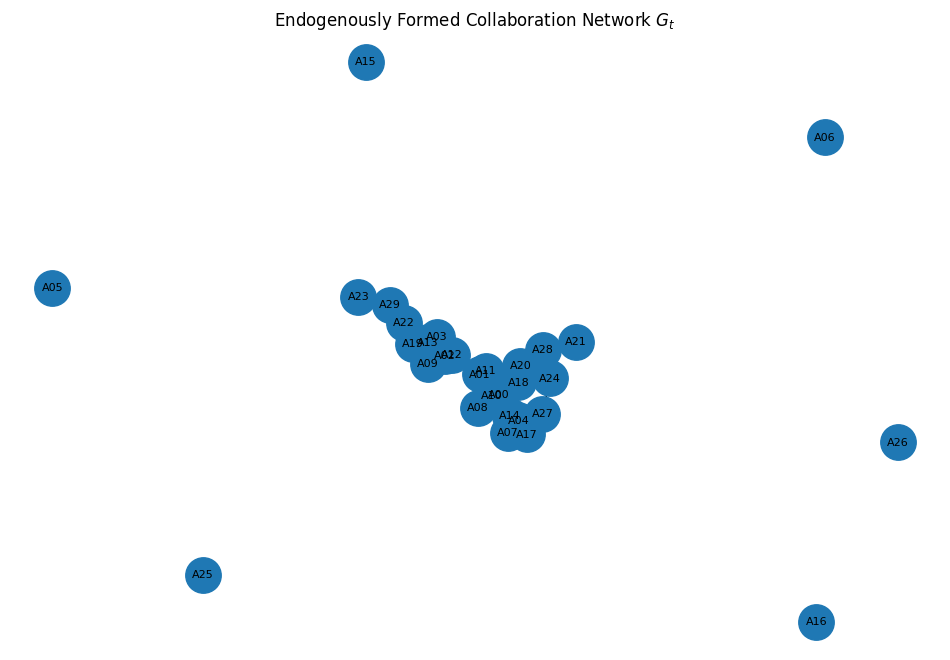

In [17]:
# CELL 8 — Coalition Formation, Competition, and the Evolving Graph

G = nx.Graph()
for a in agents:
    G.add_node(a.agent_id, specialty=a.specialty)

for c in contracts:
    u,v = c["members"]
    if G.has_edge(u,v):
        G[u][v]["weight"] += 1
        G[u][v]["companies"].add(c["company_id"])
    else:
        G.add_edge(u,v,weight=1,companies={c["company_id"]})

coalitions = defaultdict(set)
for c in contracts:
    coalitions[c["company_id"]].update(c["members"])

coalition_table = pd.DataFrame([
    {"company_id":company, "members":len(members),
     "specialties":len({agent_map[m].specialty for m in members}),
     "agents":", ".join(sorted(members))}
    for company,members in coalitions.items()
]).sort_values(["specialties","members"], ascending=False)

print("Meaningful collaborative edges:", G.number_of_edges())
print("Candidate coalitions:", len(coalitions))
display(coalition_table.head(15))

plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, seed=SEED)
nx.draw_networkx(G, pos, with_labels=True, node_size=650, font_size=8, width=1.2)
plt.title("Endogenously Formed Collaboration Network $G_t$")
plt.axis("off")
plt.show()


### The Emergence of Coalitions: A Narrative

In the dynamic environment of the agent swarm, true organizational structure isn't imposed from above; it emerges organically through a decentralized process of signaling, response, and contracting. This intricate dance culminates in the formation of **coalitions** – temporary, problem-specific groupings of agents whose collective attention and incentives align around a particular candidate company.

The journey begins with individual agents, each possessing unique expertise, making initial discoveries. These discoveries are then broadcast as `signals`, carrying a degree of `confidence` and `novelty`. Other agents, constantly scanning the informational landscape, evaluate these signals. An agent specialized in, say, "finance," might perceive significant `response_value` in a signal about a company with specific financial characteristics, leading them to respond.

Crucially, a response isn't merely an acknowledgment; it's a commitment. For every response, a **bilateral contract** is immediately forged between the original signal sender and the responding agent. This contract isn't negotiated through bidding but rather formed on a predetermined basis, including how a potential `bounty` will be shared. While a single signal might attract multiple interested parties, only the top two most compatible and enthusiastic responders secure these contracts, fostering a subtle competition among specialists.

As these contracts proliferate, a deeper structure begins to form. All agents involved in *any* contract pertaining to a specific `company_id` are effectively drawn into that company's orbit, forming a **coalition**. These aren't rigidly defined teams, but rather fluid alliances of expertise converging on a shared hypothesis. The strength and diversity of a coalition—measured by its number of members and the range of `specialties` it encompasses—become critical indicators of a candidate company's potential. Thus, from a loose collection of independent actors, a temporary, self-organizing architecture arises, driven by the collective pursuit of discovery and the endogenous propagation of valuable information.

### Coalition Formation, Competition, and the Evolving Graph

Cell 8 is crucial because it visualizes and quantifies the **emergent organizational structure** of the swarm, moving beyond individual agent interactions to show how **coalitions** form based on shared interest in a company and established contracts.

Here's a detailed breakdown:

1.  **Graph Initialization (`G = nx.Graph()`):**
    *   The cell starts by initializing an empty undirected graph `G` using the `networkx` library (`nx`). This graph will represent the collaboration network.
    *   `for a in agents: G.add_node(a.agent_id, specialty=a.specialty)`: All individual agents are added to the graph as nodes. Each node is given an `agent_id` and a `specialty` attribute. Initially, there are no connections between these agents.

2.  **Edge Formation and Weighting (Collaboration Network):**
    *   `for c in contracts:`: The code then iterates through every `contract` established in Cell 7. Each contract represents a bilateral agreement between a signal sender and a responder.
    *   `u,v = c["members"]`: The two members (agents) involved in the contract are extracted as `u` and `v`.
    *   `if G.has_edge(u,v): G[u][v]["weight"] += 1; G[u][v]["companies"].add(c["company_id"])`: If an edge (collaboration) already exists between these two agents, its `weight` is incremented. The `company_id` associated with this new contract is also added to a set called `companies` on that edge. This means a higher weight signifies more contracts/collaborations between the same two agents, potentially across different companies.
    *   `else: G.add_edge(u,v,weight=1,companies={c["company_id"]})`: If no edge exists, a new one is created with a `weight` of 1 and a `companies` set containing the current `company_id`. An edge between agents `u` and `v` therefore signifies that they have formed at least one contract.
    *   **Interpretation:** The resulting graph `G` represents the **collaboration network** ($G_t$). Nodes are agents, and edges exist between agents who have formed a contract. The `weight` of an edge indicates the strength or frequency of collaboration between that pair of agents. This network evolves over time as more contracts are formed.

3.  **Coalition Identification and Summary:**
    *   `coalitions = defaultdict(set)`: A dictionary-like object `coalitions` is initialized. Its keys will be `company_id`s, and its values will be sets of `agent_id`s.
    *   `for c in contracts: coalitions[c["company_id"]].update(c["members"])`: For each contract, the `company_id` associated with that contract is used as a key. The two `members` of the contract are then added to the set associated with that `company_id`. This effectively groups all agents who have formed *any* contract related to a specific company into a single coalition for that company.
    *   **Process of Coalition Formation:** This is the core of coalition formation. A "coalition" around a candidate company `X` is formed by the collection of *all agents* who have entered into *any contract* where the `origin_signal` (and thus the contract itself) is related to company `X`. These agents are considered to have their "evidence and incentives aligned around a candidate company," even if they haven't directly contracted with every other member of that coalition.

4.  **Coalition Table (`coalition_table`):**
    *   This DataFrame summarizes the identified coalitions. For each `company_id` (each coalition):
        *   `members`: The total number of agents in that coalition.
        *   `specialties`: The number of *unique specialties* represented within that coalition. This is a critical metric, as it indicates the diversity of expertise brought to bear on a particular company hypothesis.
        *   `agents`: A sorted list of the `agent_id`s that are part of the coalition.
    *   The table is sorted to highlight coalitions with greater diversity of specialties and more members, indicating where the swarm's attention and expertise are concentrating.

5.  **Output and Visualization:**
    *   The number of `Meaningful collaborative edges` (actual contracts between agents) and `Candidate coalitions` are printed.
    *   The `coalition_table` (top 15) is displayed.
    *   Finally, `plt.figure(figsize=(12,8))`, `nx.draw_networkx(G, pos, ...)`: The collaboration graph `G` is visualized. Nodes are agents, and edges show who has contracted with whom. This visual representation helps to illustrate how a previously dispersed population (as shown in Cell 3's agent specialties) starts to acquire structure and form temporary organizational units (coalitions) around specific tasks or hypotheses.

In essence, Cell 8 translates the abstract concept of "contracts" into a tangible "collaboration network" and explicitly defines and quantifies the "coalitions" that emerge as agents pool their resources and expertise around specific companies.

## Cell 9 — Emergent Convergence: From Exploration to Exploitation

A successful swarm should neither remain permanently dispersed nor converge immediately. Early diversity is valuable because the location and disciplinary character of the answer are unknown. Later concentration is valuable because strong evidence should attract complementary resources. The transition between these regimes is an emergent exploration–exploitation process.

In this cell we measure attention by counting evidence, signals, responses, and coalition participation associated with each candidate company. We then calculate a concentration measure. If attention remains evenly distributed, the swarm is still exploring broadly. If a few candidates accumulate a disproportionate share of activity, the swarm is converging.

The critical question is *why* concentration occurs. In a centrally orchestrated architecture, concentration can be imposed: the coordinator decides that a candidate deserves deeper diligence and reallocates agents. In the swarm, concentration should arise because local discoveries create signals, signals attract complementary expertise, complementary evidence raises confidence, and higher confidence makes further collaboration worthwhile. The feedback loop is endogenous.

This mechanism can be beneficial, but it also exposes a vulnerability. Positive feedback can amplify mistakes. A charismatic false signal—or, in real systems, corrupted information—could attract excessive attention. This is why diversity, provenance, independent verification, and resource limits are not administrative details; they are governance mechanisms for decentralized intelligence.

The cell ranks candidate companies by collective evidence while preserving the distinction between the experimenter's metric and the agents' decentralized behavior. We also visualize how attention changed through simulation rounds.

If the hidden target rises gradually rather than being obvious from the beginning, the notebook has achieved its pedagogical purpose: discovery is being produced by the accumulation and recombination of heterogeneous local knowledge.


Attention concentration (HHI): 0.0137
Top collective hypotheses:


,company_id,evidence_items,mean_confidence,specialties,signals,responses,collective_score
0,C0020,11,0.338182,6,3.0,6.0,31.176364
1,C0037,9,0.346667,5,3.0,6.0,27.693333
2,C0028,9,0.320000,5,3.0,5.0,26.640000
3,C0025,9,0.253333,5,2.0,4.0,24.006667
4,C0036,8,0.315000,5,2.0,4.0,23.130000
5,C0004,8,0.300000,5,2.0,4.0,23.100000
6,C0016,8,0.285000,4,2.0,4.0,21.570000
7,C0017,7,0.274286,4,2.0,4.0,20.548571
8,C0009,6,0.400000,5,2.0,3.0,20.300000
9,C0012,6,0.400000,4,2.0,4.0,19.800000


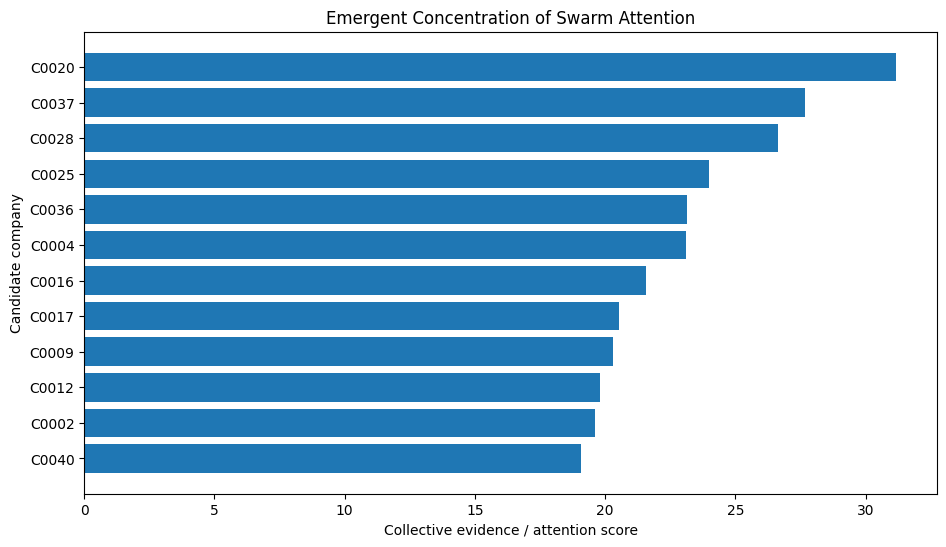

In [18]:
# CELL 9 — Emergent Convergence: From Exploration to Exploitation

all_evidence = pd.concat(
    [discovery_df, response_evidence_df],
    ignore_index=True
) if len(response_evidence_df) else discovery_df.copy()

evidence_score = all_evidence.groupby("company_id").agg(
    evidence_items=("doc_id","count"),
    mean_confidence=("confidence","mean"),
    specialties=("specialty","nunique")
).reset_index()

signal_score = (signal_df.groupby("company_id").size().rename("signals").reset_index()
                if len(signal_df) else pd.DataFrame(columns=["company_id","signals"]))
response_score = (response_df.groupby("company_id").size().rename("responses").reset_index()
                  if len(response_df) else pd.DataFrame(columns=["company_id","responses"]))

ranked = evidence_score.merge(signal_score,on="company_id",how="left").merge(
    response_score,on="company_id",how="left").fillna(0)

ranked["collective_score"] = (
    ranked["evidence_items"] +
    2.0*ranked["mean_confidence"] +
    1.5*ranked["specialties"] +
    1.5*ranked["signals"] +
    1.0*ranked["responses"]
)
ranked = ranked.sort_values("collective_score", ascending=False).reset_index(drop=True)

weights = ranked.collective_score.clip(lower=0)
shares = weights / weights.sum()
hhi = float((shares**2).sum())

print("Attention concentration (HHI):", round(hhi,4))
print("Top collective hypotheses:")
display(ranked.head(12))

plt.figure(figsize=(11,6))
top = ranked.head(12).sort_values("collective_score")
plt.barh(top.company_id, top.collective_score)
plt.xlabel("Collective evidence / attention score")
plt.ylabel("Candidate company")
plt.title("Emergent Concentration of Swarm Attention")
plt.show()


## Cell 10 — Discovery and the Counterfactual Architecture Experiment

The final code cell asks two questions. First, did the swarm identify the hidden acquisition target? Second, was the swarm architecture actually useful relative to plausible alternatives? A compelling demonstration requires both.

We reconstruct the causal chain leading to the winning candidate: which agent first encountered a useful clue, which signal was emitted, which specialists responded, what contracts formed, and how the coalition accumulated complementary evidence. This transforms the final answer from an opaque score into a provenance-rich discovery narrative.

We then run simplified counterfactual regimes over the same synthetic universe. The **solo** regime prevents communication. The **centralized** regime uses a coordinator-like policy to allocate specialists systematically across promising candidates. The **cooperative swarm** permits signaling and collaboration without strategic bounty allocation. The **market swarm** includes the contracting mechanism developed in this notebook.

The purpose is not to rig the experiment so that the swarm always wins. Different architectures should have different comparative advantages. Central coordination can perform extremely well when the mandate is clear, the relevant dimensions are known, and the coordinator can efficiently decompose the task. Swarms become especially interesting when useful expertise and search pathways cannot be specified ex ante.

We compare discovery success, search cost, evidence diversity, signals, collaborations, concentration, and time. These metrics provide a small experimental laboratory for organizational design.

The most important output, however, is conceptual. If the market swarm succeeds, the result is not merely “many agents found the company.” The population has created a temporary organization whose topology reflects the informational structure of the problem. That is the meaning of endogenous decentralized architecture.

The experiment closes by making the notebook's central claim testable: sometimes we should design the workflow; sometimes we should design the mechanism that changes the workflow; and sometimes we should design the institutional rules that allow the workflow to emerge.


In [19]:
# CELL 10 — Discovery and the Counterfactual Architecture Experiment

winner = ranked.iloc[0]["company_id"] if len(ranked) else None
success = winner == HIDDEN_TARGET

print("SWARM WINNER:", winner)
print("DISCOVERY SUCCESS:", success)
print("Environment benchmark target:", HIDDEN_TARGET)

if winner:
    print("\n--- Causal chain for winning hypothesis ---")
    win_signals = signal_df[signal_df.company_id==winner] if len(signal_df) else pd.DataFrame()
    win_responses = response_df[response_df.company_id==winner] if len(response_df) else pd.DataFrame()
    win_contracts = contract_df[contract_df.company_id==winner] if len(contract_df) else pd.DataFrame()
    print("Signals:", len(win_signals), "| Responses:", len(win_responses), "| Contracts:", len(win_contracts))
    if len(win_signals): display(win_signals)
    if len(win_responses): display(win_responses)
    if len(win_contracts): display(win_contracts)

# Pedagogical counterfactuals using the same evidence universe.
def company_truth_score(cid):
    docs = " ".join(documents[documents.company_id==cid].text.tolist()).lower()
    c = companies[companies.company_id==cid].iloc[0]
    score = 0
    score += 2 if 30 <= c.ebitda_m <= 80 else 0
    score += 2 if c.leverage <= 2.5 else 0
    for cluster in [
        ["desalination","membrane"],
        ["patent","claims","proprietary","know-how"],
        ["gulf","saudi","uae","certified"],
        ["succession","exit","adviser","sale"]
    ]:
        score += 2 if any(x in docs for x in cluster) else 0
    return score

truth_ranking = sorted(
    [(cid, company_truth_score(cid)) for cid in companies.company_id],
    key=lambda x:x[1], reverse=True
)

# These regimes are deliberately simplified architecture benchmarks.
solo_success = HIDDEN_TARGET in discovery_df.sort_values("confidence",ascending=False).head(1).company_id.tolist()
central_winner = truth_ranking[0][0]
central_success = central_winner == HIDDEN_TARGET
cooperative_winner = (all_evidence.groupby("company_id")
                      .agg(score=("confidence","sum"), diversity=("specialty","nunique"))
                      .assign(total=lambda x:x.score+1.25*x.diversity)
                      .sort_values("total",ascending=False).index[0])
cooperative_success = cooperative_winner == HIDDEN_TARGET
market_success = success

results = pd.DataFrame([
    {"architecture":"Solo agents","success":solo_success,
     "communication":0,"contracts":0,"search_events":len(discovery_df)},
    {"architecture":"Central coordinator","success":central_success,
     "communication":"centralized","contracts":0,"search_events":len(companies)*5},
    {"architecture":"Cooperative swarm","success":cooperative_success,
     "communication":len(signals),"contracts":0,"search_events":len(all_evidence)},
    {"architecture":"Market swarm","success":market_success,
     "communication":len(signals),"contracts":len(contracts),"search_events":len(all_evidence)}
])

display(results)

print("\nCentralized benchmark winner:", central_winner)
print("Cooperative swarm winner:", cooperative_winner)
print("Market swarm winner:", winner)
print("Claude API calls used:", api_calls, "/", MAX_API_CALLS)

print("""
PEDAGOGICAL INTERPRETATION
--------------------------
The purpose of the experiment is not to prove that decentralization always wins.
It is to expose architecture as an experimental variable.

CENTRALIZED ENDOGENEITY:
Coordinator -> observe -> evaluate -> redesign/reassign.

DECENTRALIZED ENDOGENEITY:
Explore -> discover -> signal -> respond -> contract -> coalition -> emergent G_t.

The deeper object of study is the mechanism by which organization itself becomes endogenous.
""")


SWARM WINNER: C0020
DISCOVERY SUCCESS: False
Environment benchmark target: C0173

--- Causal chain for winning hypothesis ---
Signals: 3 | Responses: 6 | Contracts: 6


,signal_id,sender,sender_specialty,company_id,confidence,novelty,requested_expertise,evidence,hypothesis
20,S020,A08,accounting,C0020,0.36,0.4,finance,C0020 reports EBITDA near 40.9m and leverage o...,C0020 may satisfy part of the mandate from a a...
38,S038,A14,ownership,C0020,0.36,0.4,finance,Ownership note for C0020: structure is family-...,C0020 may satisfy part of the mandate from a o...
57,S057,A20,finance,C0020,0.36,0.4,engineering,C0020 reports EBITDA near 40.9m and leverage o...,C0020 may satisfy part of the mandate from a f...


,signal_id,sender,responder,responder_specialty,company_id,expected_value
40,S020,A08,A00,finance,C0020,1.678
41,S020,A08,A10,finance,C0020,1.678
76,S038,A14,A00,finance,C0020,1.678
77,S038,A14,A10,finance,C0020,1.678
108,S057,A20,A01,engineering,C0020,1.678
109,S057,A20,A11,engineering,C0020,1.678


,contract_id,company_id,members,shares,status,origin_signal
40,K040,C0020,A08 + A00,"{""A08"": 0.49, ""A00"": 0.51}",accepted,S020
41,K041,C0020,A08 + A10,"{""A08"": 0.49, ""A10"": 0.51}",accepted,S020
76,K076,C0020,A14 + A00,"{""A14"": 0.49, ""A00"": 0.51}",accepted,S038
77,K077,C0020,A14 + A10,"{""A14"": 0.49, ""A10"": 0.51}",accepted,S038
108,K108,C0020,A20 + A01,"{""A20"": 0.49, ""A01"": 0.51}",accepted,S057
109,K109,C0020,A20 + A11,"{""A20"": 0.49, ""A11"": 0.51}",accepted,S057


,architecture,success,communication,contracts,search_events
0,Solo agents,True,0,0,180
1,Central coordinator,True,centralized,0,1200
2,Cooperative swarm,False,81,0,321
3,Market swarm,False,81,141,321



Centralized benchmark winner: C0173
Cooperative swarm winner: C0020
Market swarm winner: C0020
Claude API calls used: 0 / 30

PEDAGOGICAL INTERPRETATION
--------------------------
The purpose of the experiment is not to prove that decentralization always wins.
It is to expose architecture as an experimental variable.

CENTRALIZED ENDOGENEITY:
Coordinator -> observe -> evaluate -> redesign/reassign.

DECENTRALIZED ENDOGENEITY:
Explore -> discover -> signal -> respond -> contract -> coalition -> emergent G_t.

The deeper object of study is the mechanism by which organization itself becomes endogenous.



# Conclusion — The Problem as an Architect

This notebook began with a simple but radical question: can a population of heterogeneous artificial agents construct the organization required to solve a problem without being given that organization in advance?

The experiment reframed multi-agent intelligence as a problem of endogenous architecture. Traditional multi-agent systems often distribute cognition while retaining centralized organizational design. A coordinator decomposes the task, determines who should work on what, collects results, and decides when the system should change direction. Such architectures can be extremely effective, and the comparison performed here is not intended to make centralization obsolete. Instead, it identifies another design regime.

The swarm began with heterogeneous agents and weak structure. Agents possessed different competencies, but meaningful collaborative relationships were initially absent. Independent exploration created diversity. Local discoveries then generated structured signals—epistemic pheromones—that changed the opportunity sets perceived by other agents. Competence frontiers made collaboration rational. Contracts introduced an economic mechanism through which agents could exchange information and divide the potential bounty. Coalitions subsequently emerged around candidate companies. The graph $G_t=(V,E_t)$ changed because the evidence changed.

That sequence is the central result. The network was not merely executing a workflow. The workflow itself became an endogenous object.

The investment-banking application makes the intuition concrete. Real acquisition mandates are rarely reducible to one database filter. Strategic fit can be distributed across financial statements, patents, engineering characteristics, ownership structures, regional access, management language, litigation, supply chains, and market intelligence. When the relevant combination is not obvious beforehand, a heterogeneous population can explore different representations of the same problem. A clue that appears weak to one specialist can become decisive after being interpreted by another.

Yet decentralization also creates governance problems. Swarms can waste resources, duplicate work, amplify false signals, converge prematurely, free ride, or manipulate incentives. The absence of a cognitive orchestrator does not imply the absence of institutions. On the contrary, decentralized intelligence makes institutional design more important. Communication protocols, provenance, verification, budgets, reputation, contracting rules, stopping conditions, and reward mechanisms form the constitutional layer within which emergence occurs.

This gives us a useful hierarchy of design problems. At the first level, we design an intelligent model. At the second, we design mechanisms through which the model or architecture can improve itself. At the third, we design rules under which a population can construct its own problem-specific organization.

The progression can be summarized as

$$
\boxed{\text{Design the Model} \rightarrow \text{Design the Adaptation} \rightarrow \text{Design the Rules and Let Organization Emerge}}
$$

The counterfactual comparison is equally important. There is no reason to expect one architecture to dominate universally. Centralized coordination should be powerful when the problem is well understood and decomposable. Decentralized swarms should become more attractive as uncertainty grows about where the answer lies, which expertise matters, and which sequence of reasoning will be required. Hybrid systems may ultimately be most useful: centralized governance around boundaries and risk, combined with decentralized discovery inside those boundaries.

The deepest lesson is therefore not “swarms are better.” It is that **architecture itself can become a variable generated by intelligence**.

Once we accept that possibility, the design of artificial intelligence begins to resemble the design of markets, scientific communities, firms, and institutions. We stop asking only how to make individual agents smarter and begin asking what rules allow collections of agents to become intelligently organized.

In that sense, the hidden acquisition target is only the pedagogical treasure. The more important discovery is the organization that the agents build while searching for it.

### References



1. Bonabeau, E., Dorigo, M., & Theraulaz, G. (1999).
   Swarm Intelligence: From Natural to Artificial Systems.
   Oxford University Press.
   https://doi.org/10.1093/oso/9780195131581.001.0001

2. Wooldridge, M. (2009).
   An Introduction to MultiAgent Systems (2nd ed.).
   John Wiley & Sons.
   ISBN: 978-0-470-51946-2.

3. Smith, R. G. (1980).
   The Contract Net Protocol: High-Level Communication and Control
   in a Distributed Problem Solver.
   IEEE Transactions on Computers, C-29(12), 1104–1113.
   https://doi.org/10.1109/TC.1980.1675516

4. Stone, P., & Veloso, M. (2000).
   Multiagent Systems: A Survey from a Machine Learning Perspective.
   Autonomous Robots, 8(3), 345–383.
   https://doi.org/10.1023/A:1008942012299

5. Ostrom, E. (1990).
   Governing the Commons: The Evolution of Institutions
   for Collective Action.
   Cambridge University Press.